This problem involves the Boston data set, which we saw in the lab
for this chapter. We will now try to predict per capita crime rate
using the other variables in this data set. In other words, per capita
crime rate is the response, and the other variables are the predictors.

In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

(a) For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

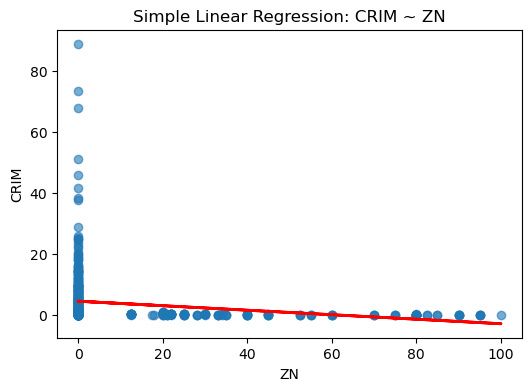

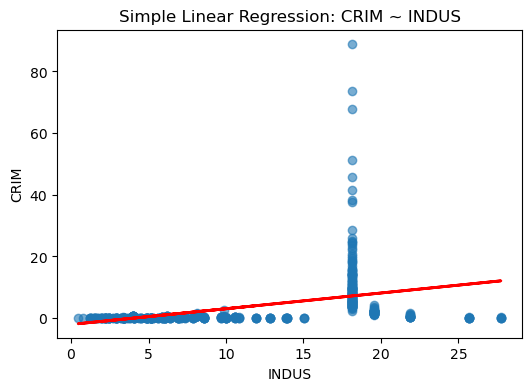

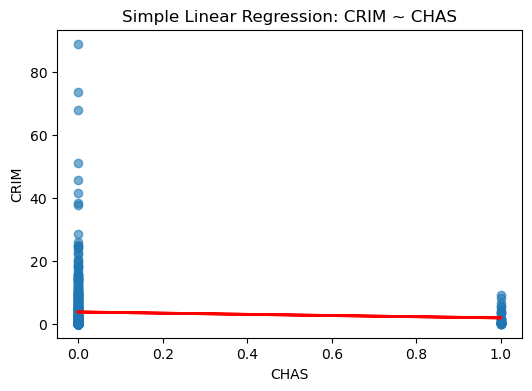

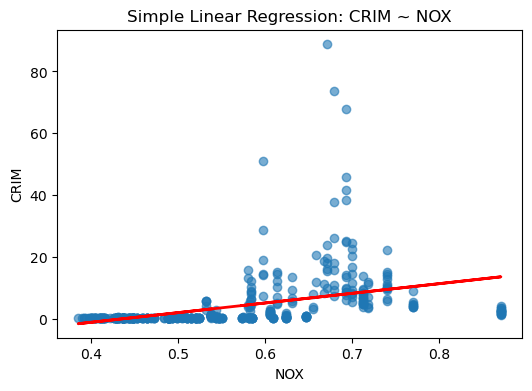

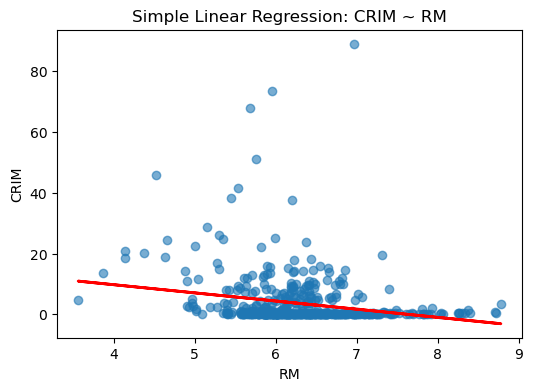

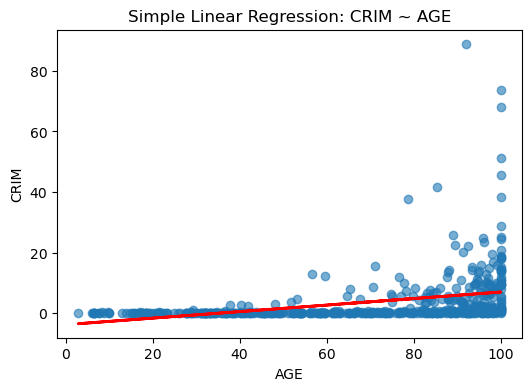

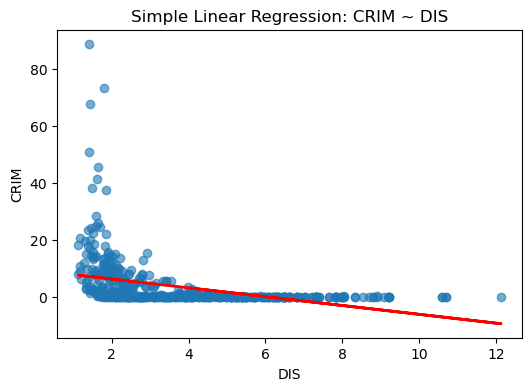

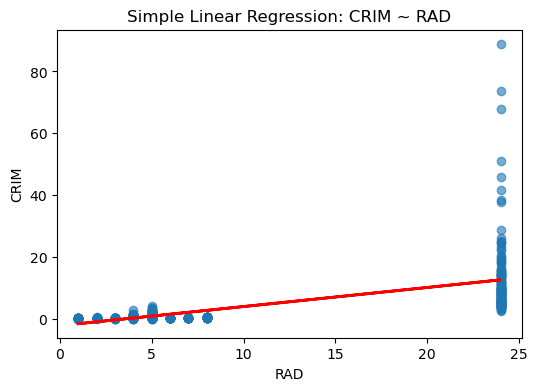

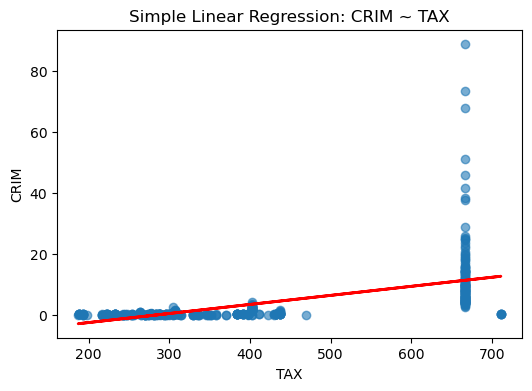

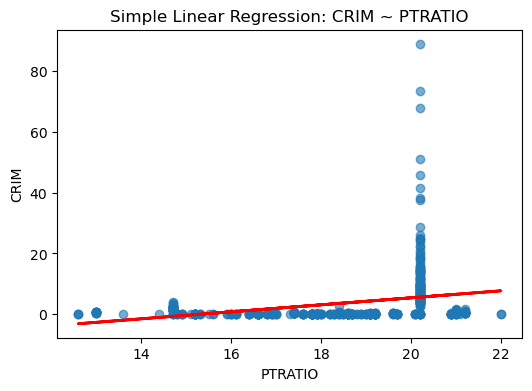

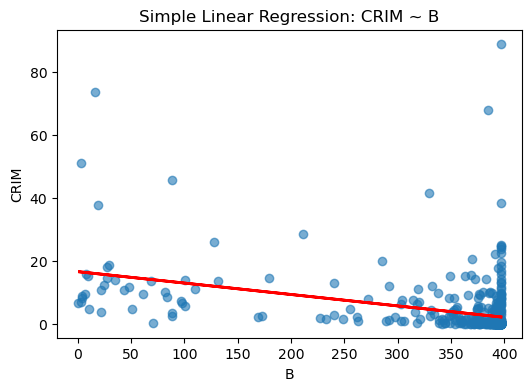

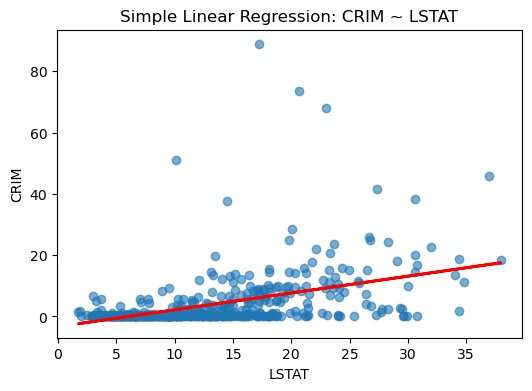

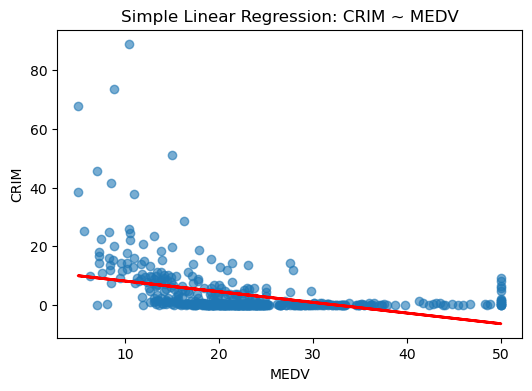

   Predictor  Coefficient       p-value  R-squared
0         ZN    -0.073935  5.506472e-06   0.040188
1      INDUS     0.509776  1.450349e-21   0.165310
2       CHAS    -1.892777  2.094345e-01   0.003124
3        NOX    31.248531  3.751739e-23   0.177217
4         RM    -2.684051  6.346703e-07   0.048069
5        AGE     0.107786  2.854869e-16   0.124421
6        DIS    -1.550902  8.519949e-19   0.144149
7        RAD     0.617911  2.693844e-56   0.391257
8        TAX     0.029742  2.357127e-47   0.339614
9    PTRATIO     1.151983  2.942922e-11   0.084068
10         B    -0.036280  2.487274e-19   0.148274
11     LSTAT     0.548805  2.654277e-27   0.207591
12      MEDV    -0.363160  1.173987e-19   0.150780


In [4]:
# 載入 Boston dataset
boston = fetch_openml(name="Boston", version=1, as_frame=True)
df = boston.frame

# response: per capita crime rate
y = df['CRIM']

# predictors: 其他變數
X = df.drop(columns=['CRIM']).astype(float)

# 用來存放回歸結果
results_summary = []

# 對每個變數做簡單線性回歸
for col in X.columns:
    X_col = sm.add_constant(X[col])  # 加截距
    model = sm.OLS(y, X_col).fit()
    results_summary.append({
        'Predictor': col,
        'Coefficient': model.params[col],
        'p-value': model.pvalues[col],
        'R-squared': model.rsquared
    })
    
    # 畫散點圖 + 回歸線
    plt.figure(figsize=(6,4))
    plt.scatter(X[col], y, alpha=0.6)
    plt.plot(X[col], model.predict(X_col), color='red', linewidth=2)
    plt.xlabel(col)
    plt.ylabel('CRIM')
    plt.title(f'Simple Linear Regression: CRIM ~ {col}')
    plt.show()

# 將結果整理成 DataFrame
results_df = pd.DataFrame(results_summary)
print(results_df)

Based on the scatter plots, for each predictor (NOX, RM, AGE, DIS, LSTAT, and MEDV) individually, the data points exhibit a trend pattern similar to that of the linear regression line.
Based on the p-values, all predictors except CHAS show a statistically significant association with the crime rate (response) when considered individually.

(b) Fit a multiple regression model to predict the response using
all of the predictors. Describe your results. For which predictors
can we reject the null hypothesis H0 : βj = 0?

In [5]:
# 加入截距
X_const = sm.add_constant(X)

# 建立多元線性回歸
model_multi = sm.OLS(y, X_const).fit()

# 顯示完整回歸結果
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                   CRIM   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     31.47
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           1.57e-56
Time:                        23:41:13   Log-Likelihood:                -1653.3
No. Observations:                 506   AIC:                             3335.
Df Residuals:                     492   BIC:                             3394.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.0332      7.235      2.354      0.0

Based on the multiple linear regression using all predictors to predict CRIM: the model is statistically significant overall (F=31.47, p-value < 0.001) and explains about 45% of the variability in CRIM (R-squared = 0.454). Among the predictors, ZN, DIS, and RAD have statistically significant coefficients (p < 0.05), so we can reject the null hypothesis H0 : βj = 0 for these variables. The other predictors do not show significant effects in the presence of the others.

(c) How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regres-
sion model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

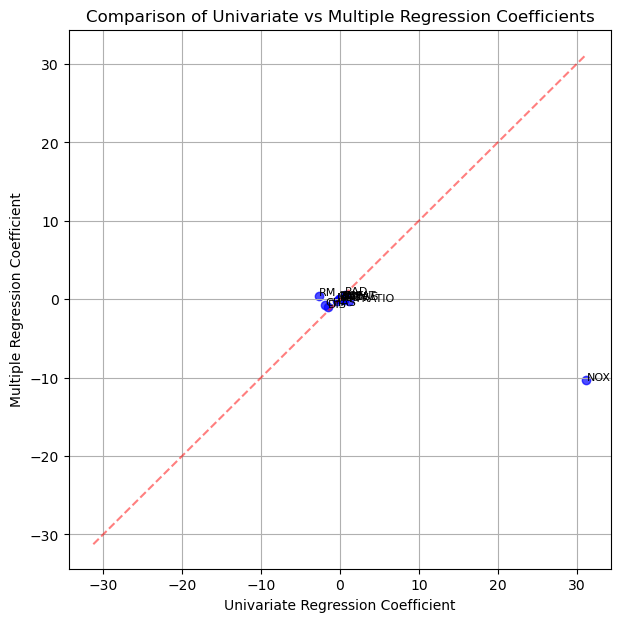

In [17]:
# 多元回歸係數 (去掉截距)
multi_coefs = model_multi.params.drop('const')

# 合併單變量與多元回歸係數
coef_compare = results_df[['Predictor', 'Coefficient']].copy()
coef_compare = coef_compare.rename(columns={'Coefficient':'Univariate_Coeff'})
coef_compare['Multivariate_Coeff'] = coef_compare['Predictor'].map(multi_coefs)

plt.figure(figsize=(7,7))
plt.scatter(coef_compare['Univariate_Coeff'], coef_compare['Multivariate_Coeff'], color='blue', alpha=0.7)

# 加入 y=x 參考線
max_val = coef_compare[['Univariate_Coeff','Multivariate_Coeff']].abs().max().max()
plt.plot([-max_val, max_val], [-max_val, max_val], 'r--', alpha=0.5)

for i, row in coef_compare.iterrows():
    plt.text(row['Univariate_Coeff'], row['Multivariate_Coeff'], row['Predictor'], fontsize=8)

plt.xlabel('Univariate Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Comparison of Univariate vs Multiple Regression Coefficients')
plt.grid(True)
plt.show()



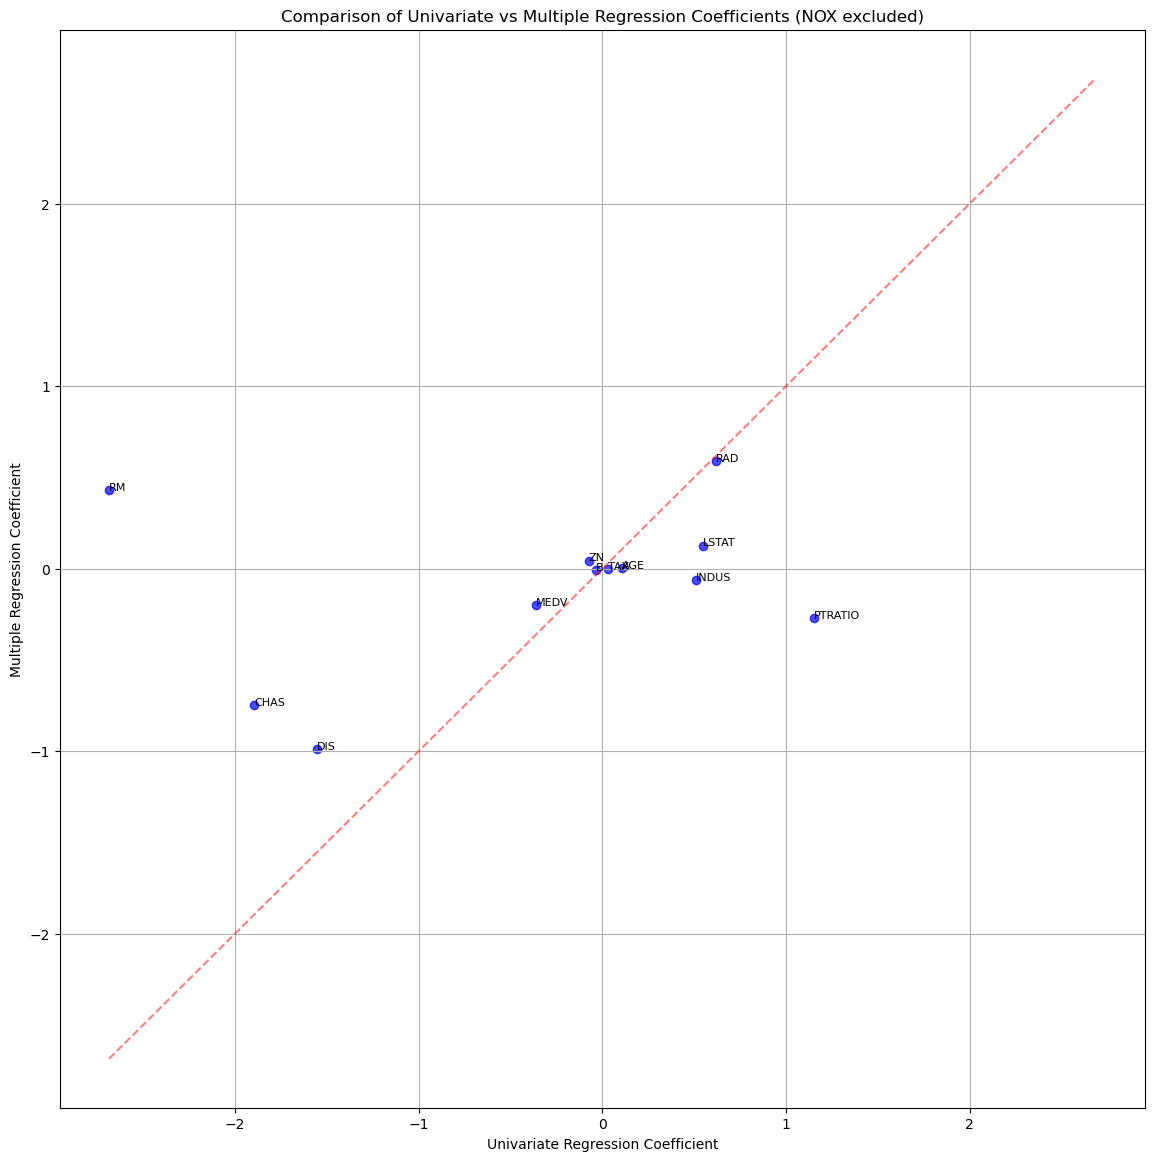

In [19]:
# 過濾掉 NOX
coef_plot = coef_compare[coef_compare['Predictor'] != 'NOX']

plt.figure(figsize=(14,14))
plt.scatter(coef_plot['Univariate_Coeff'], coef_plot['Multivariate_Coeff'], color='blue', alpha=0.7)

# y=x 參考線
max_val = coef_plot[['Univariate_Coeff','Multivariate_Coeff']].abs().max().max()
plt.plot([-max_val, max_val], [-max_val, max_val], 'r--', alpha=0.5)

# 標註變數名稱
for i, row in coef_plot.iterrows():
    plt.text(row['Univariate_Coeff'], row['Multivariate_Coeff'], row['Predictor'], fontsize=8)

plt.xlabel('Univariate Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Comparison of Univariate vs Multiple Regression Coefficients (NOX excluded)')
plt.grid(True)
plt.show()

Most of the data points do not lie on the x=y line, which means that the coefficients in the univariate regression differ from those in the multiple regression. This suggests that the effect of a predictor on the response can be influenced by the presence of other predictors.

(d) Is there evidence of non-linear association between any of the
predictors and the response? To answer this question, for each
predictor X, fit a model of the form
Y= β0 + β1X + β2X2 + β3X3 + ϵ.

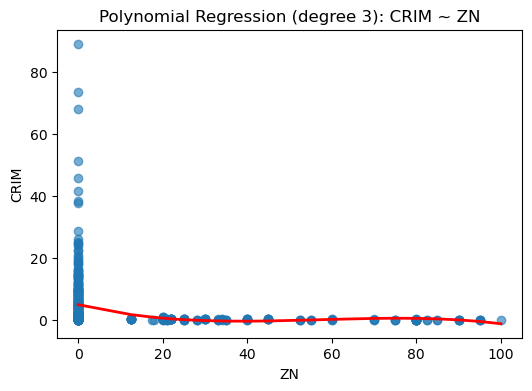

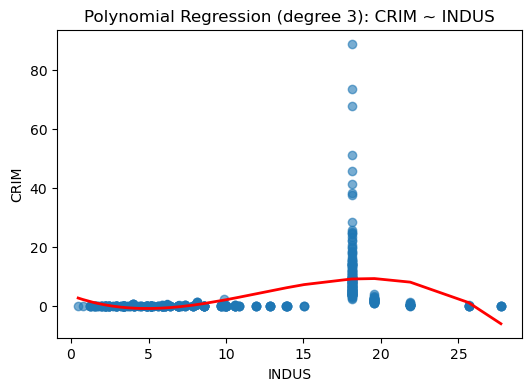

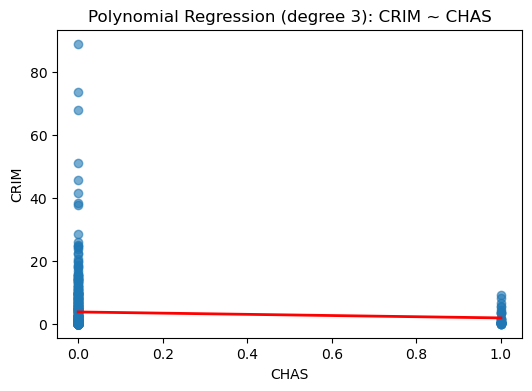

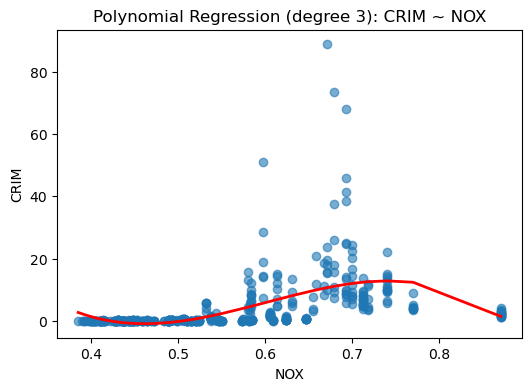

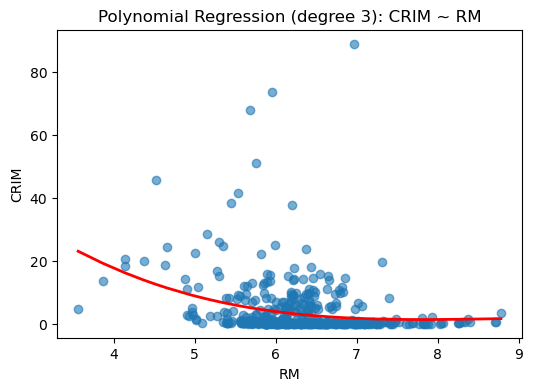

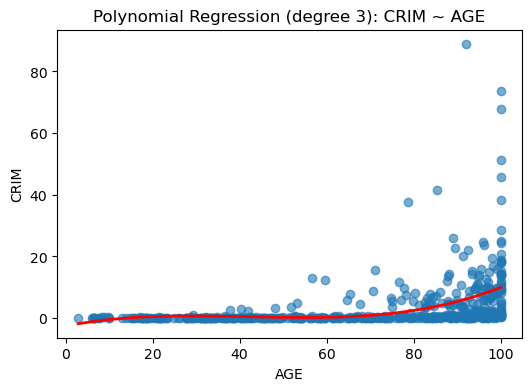

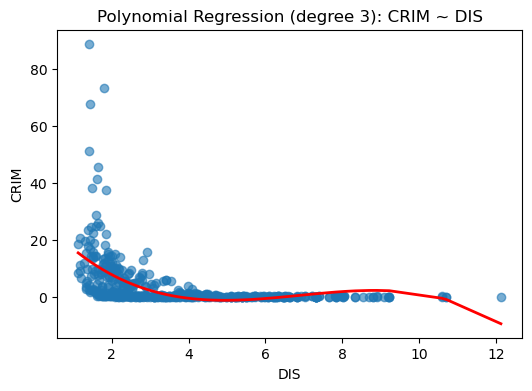

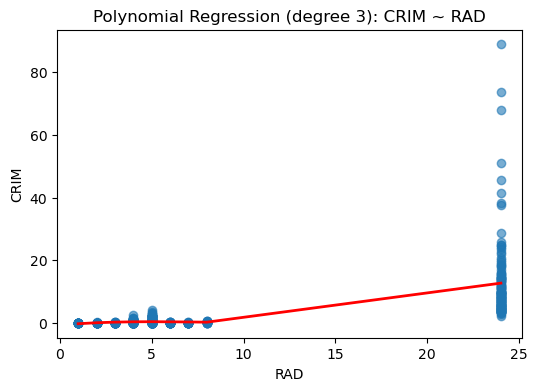

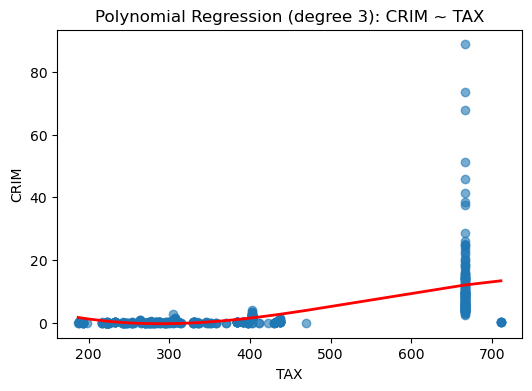

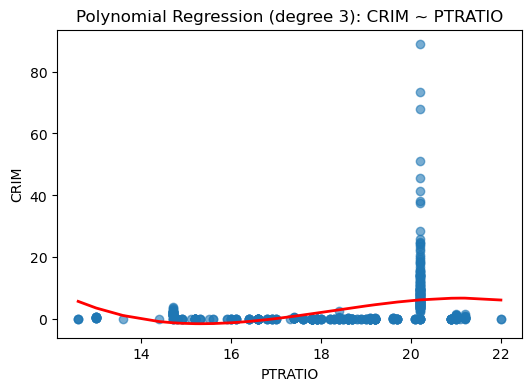

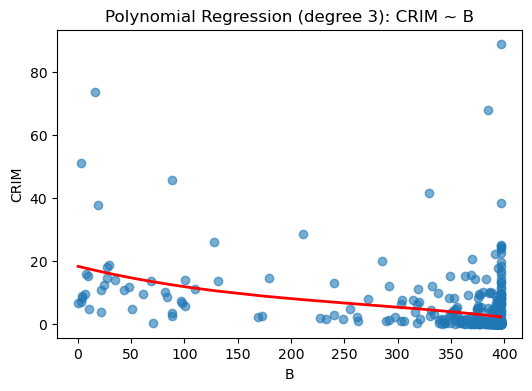

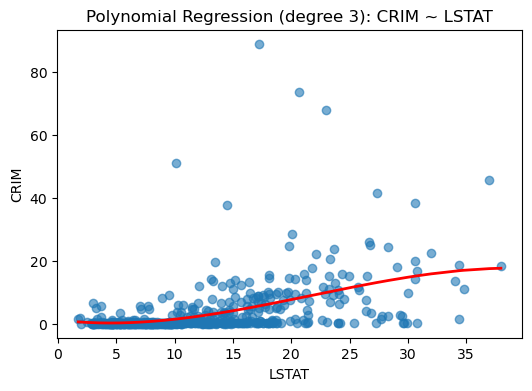

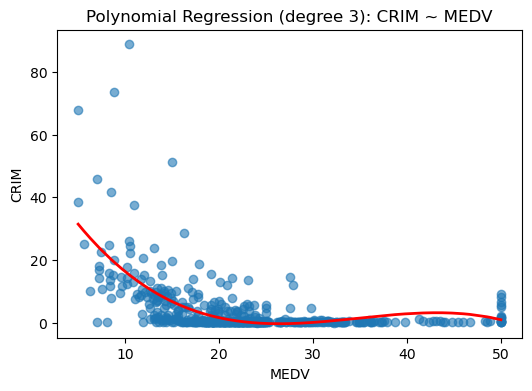

   Predictor          p_X2          p_X3
0         ZN  9.375050e-02  2.295386e-01
1      INDUS  3.420187e-10  1.196405e-12
2       CHAS  6.794093e-01  6.794093e-01
3        NOX  6.811300e-15  6.961110e-16
4         RM  3.641094e-01  5.085751e-01
5        AGE  4.737733e-02  6.679915e-03
6        DIS  4.941214e-12  1.088832e-08
7        RAD  6.130099e-01  4.823138e-01
8        TAX  1.374682e-01  2.438507e-01
9    PTRATIO  4.119552e-03  6.300514e-03
10         B  4.741751e-01  5.436172e-01
11     LSTAT  6.458736e-02  1.298906e-01
12      MEDV  3.260523e-18  1.046510e-12


In [20]:
nonlinear_results = []

for col in X.columns:
    # 建立三次多項式欄位
    X_poly = pd.DataFrame({
        'X1': X[col],
        'X2': X[col]**2,
        'X3': X[col]**3
    })
    X_poly = sm.add_constant(X_poly)  # 加截距
    
    model_poly = sm.OLS(y, X_poly).fit()
    
    # 存放 p-values
    nonlinear_results.append({
        'Predictor': col,
        'p_X2': model_poly.pvalues['X2'],
        'p_X3': model_poly.pvalues['X3']
    })
    
    # 畫散點圖 + 擬合曲線
    plt.figure(figsize=(6,4))
    plt.scatter(X[col], y, alpha=0.6)
    x_range = pd.Series(sorted(X[col]))
    y_pred = model_poly.predict(sm.add_constant(pd.DataFrame({
        'X1': x_range,
        'X2': x_range**2,
        'X3': x_range**3
    })))
    plt.plot(x_range, y_pred, color='red', linewidth=2)
    plt.xlabel(col)
    plt.ylabel('CRIM')
    plt.title(f'Polynomial Regression (degree 3): CRIM ~ {col}')
    plt.show()

# 將結果整理成 DataFrame
nonlinear_df = pd.DataFrame(nonlinear_results)
print(nonlinear_df)

Based on the cubic polynomial regression, several predictors show evidence of a non-linear association with CRIM. Specifically, INDUS, NOX, AGE, DIS, PTRATIO, and MEDV have statistically significant quadratic (X²) or cubic (X³) terms (p < 0.05), indicating non-linear effects. The remaining predictors do not show significant non-linear terms, suggesting an approximately linear relationship with the response.